# CIFAR-100-LT Experiments

## 1. Setup

In [2]:
# Install dependencies (run once)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install matplotlib tqdm

Looking in indexes: https://download.pytorch.org/whl/cu124


In [3]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.6.0+cu124
CUDA: True
GPU: NVIDIA GeForce RTX 3050


In [5]:
# Import the experiment module
# Make sure CIFAR100LT_Experiments.py is in the same directory
from CIFAR100LT_Experiments import *

## 2. Quick Test (5 epochs, 1 seed)

In [6]:
# Quick test to verify everything works
test_config = CONFIG.copy()
test_config['epochs'] = 5
test_config['save_dir'] = './results_test'

result = run_single_experiment('uniform', 100, 42, test_config)
print(f"\nTest run complete! Acc: {result['best_acc']:.2f}%")


  Strategy: uniform | rho: 100 | Seed: 42

  CIFAR-100-LT (rho=100)
  Total training samples: 10847
  Max class size: 500
  Min class size: 5
  Median class size: 51
  Head/Medium/Tail classes: 35/34/31
  Model parameters: 472,756


uniform|rho=100|s=42: 100%|██████████| 5/5 [01:48<00:00, 21.74s/it, lr=0.1000, loss=3.076, acc=9.7, H/M/T=25/3/0]



  Best Test Acc: 9.69%
  Final (best ckpt): Overall=9.69%, Head=25.11%, Medium=2.65%, Tail=0.00%
  Saved: ./results_test\results_uniform_rho100_seed42.json

Test run complete! Acc: 9.69%


## 3. Run Full Experiments

### Option A: Run all at once

In [ ]:
# Run everything (supports resuming)
all_results = run_all_experiments(CONFIG)

### Option B: Run in batches (recommended to avoid memory issues)
Run each imbalance ratio separately, allowing you to check intermediate results.

In [ ]:
# --- Batch 1: rho=100 (most important, run first) ---
for strategy in CONFIG['strategies']:
    for seed in CONFIG['seeds']:
        run_single_experiment(strategy, 100, seed, CONFIG)
        torch.cuda.empty_cache()


  Strategy: uniform | rho: 100 | Seed: 42

  CIFAR-100-LT (rho=100)
  Total training samples: 10847
  Max class size: 500
  Min class size: 5
  Median class size: 51
  Head/Medium/Tail classes: 35/34/31
  Model parameters: 472,756


uniform|rho=100|s=42: 100%|███████| 200/200 [1:08:26<00:00, 20.53s/it, lr=0.0000, loss=0.065, acc=40.2, H/M/T=66/39/12]



  Best Test Acc: 40.27%
  Final (best ckpt): Overall=40.27%, Head=66.14%, Medium=39.44%, Tail=11.97%
  Saved: ./results\results_uniform_rho100_seed42.json

  Strategy: uniform | rho: 100 | Seed: 123

  CIFAR-100-LT (rho=100)
  Total training samples: 10847
  Max class size: 500
  Min class size: 5
  Median class size: 51
  Head/Medium/Tail classes: 35/34/31
  Model parameters: 472,756


uniform|rho=100|s=123: 100%|██████| 200/200 [1:06:43<00:00, 20.02s/it, lr=0.0000, loss=0.071, acc=39.3, H/M/T=66/37/11]



  Best Test Acc: 39.30%
  Final (best ckpt): Overall=39.30%, Head=66.40%, Medium=37.47%, Tail=10.71%
  Saved: ./results\results_uniform_rho100_seed123.json

  Strategy: uniform | rho: 100 | Seed: 456

  CIFAR-100-LT (rho=100)
  Total training samples: 10847
  Max class size: 500
  Min class size: 5
  Median class size: 51
  Head/Medium/Tail classes: 35/34/31
  Model parameters: 472,756


...

square_root|rho=100|s=42: 100%|███| 200/200 [1:06:21<00:00, 19.91s/it, lr=0.0000, loss=0.084, acc=37.8, H/M/T=63/37/11]



  Best Test Acc: 37.84%
  Final (best ckpt): Overall=37.84%, Head=62.69%, Medium=36.35%, Tail=11.42%
  Saved: ./results\results_square_root_rho100_seed42.json

  Strategy: square_root | rho: 100 | Seed: 123

  CIFAR-100-LT (rho=100)
  Total training samples: 10847
  Max class size: 500
  Min class size: 5
  Median class size: 51
  Head/Medium/Tail classes: 35/34/31
  Model parameters: 472,756


square_root|rho=100|s=123: 100%|██| 200/200 [1:06:20<00:00, 19.90s/it, lr=0.0000, loss=0.089, acc=38.1, H/M/T=64/37/10]



  Best Test Acc: 38.33%
  Final (best ckpt): Overall=38.33%, Head=64.03%, Medium=37.06%, Tail=10.71%
  Saved: ./results\results_square_root_rho100_seed123.json

  Strategy: square_root | rho: 100 | Seed: 456

  CIFAR-100-LT (rho=100)
  Total training samples: 10847
  Max class size: 500
  Min class size: 5
  Median class size: 51
  Head/Medium/Tail classes: 35/34/31
  Model parameters: 472,756


square_root|rho=100|s=456:  37%|██▏   | 74/200 [24:30<41:35, 19.81s/it, lr=0.1000, loss=0.517, acc=29.6, H/M/T=51/27/8]

In [ ]:
# --- Batch 2: rho=50 ---
for strategy in CONFIG['strategies']:
    for seed in CONFIG['seeds']:
        run_single_experiment(strategy, 50, seed, CONFIG)
        torch.cuda.empty_cache()


  Strategy: uniform | rho: 50 | Seed: 42

  CIFAR-100-LT (rho=50)
  Total training samples: 12607
  Max class size: 500
  Min class size: 9
  Median class size: 72
  Head/Medium/Tail classes: 41/40/19
  Model parameters: 472,756


uniform|rho=50|s=42: 100%|██████████| 200/200 [1:18:26<00:00, 23.53s/it, lr=0.0000, loss=0.089, acc=44.1, H/M/T=65/37/14]



  Best Test Acc: 44.19%
  Final (best ckpt): Overall=44.19%, Head=64.85%, Medium=37.40%, Tail=13.89%
  Saved: ./results\results_uniform_rho50_seed42.json

  Strategy: uniform | rho: 50 | Seed: 123

  CIFAR-100-LT (rho=50)
  Total training samples: 12607
  Max class size: 500
  Min class size: 9
  Median class size: 72
  Head/Medium/Tail classes: 41/40/19
  Model parameters: 472,756


uniform|rho=50|s=123: 100%|██████████| 200/200 [1:21:11<00:00, 24.36s/it, lr=0.0000, loss=0.097, acc=43.5, H/M/T=65/36/14]



  Best Test Acc: 43.66%
  Final (best ckpt): Overall=43.66%, Head=65.34%, Medium=35.58%, Tail=13.89%
  Saved: ./results\results_uniform_rho50_seed123.json

  Strategy: uniform | rho: 50 | Seed: 456

  CIFAR-100-LT (rho=50)
  Total training samples: 12607
  Max class size: 500
  Min class size: 9
  Median class size: 72
  Head/Medium/Tail classes: 41/40/19
  Model parameters: 472,756


...

class_balanced|rho=50|s=123: 100%|██████████| 200/200 [1:13:44<00:00, 22.12s/it, lr=0.0000, loss=0.142, acc=39.5, H/M/T=57/33/14]



  Best Test Acc: 39.78%
  Final (best ckpt): Overall=39.78%, Head=57.46%, Medium=33.85%, Tail=14.11%
  Saved: ./results\results_class_balanced_rho50_seed123.json

  Strategy: class_balanced | rho: 50 | Seed: 456

  CIFAR-100-LT (rho=50)
  Total training samples: 12607
  Max class size: 500
  Min class size: 9
  Median class size: 72
  Head/Medium/Tail classes: 41/40/19
  Model parameters: 472,756


class_balanced|rho=50|s=456: 100%|██████████| 200/200 [1:14:01<00:00, 22.21s/it, lr=0.0000, loss=0.155, acc=39.7, H/M/T=58/34/13]



  Best Test Acc: 39.71%
  Final (best ckpt): Overall=39.71%, Head=57.68%, Medium=33.83%, Tail=13.32%
  Saved: ./results\results_class_balanced_rho50_seed456.json

  Strategy: square_root | rho: 50 | Seed: 42

  CIFAR-100-LT (rho=50)
  Total training samples: 12607
  Max class size: 500
  Min class size: 9
  Median class size: 72
  Head/Medium/Tail classes: 41/40/19
  Model parameters: 472,756


square_root|rho=50|s=42:  99%|█████████▉| 198/200 [1:09:16<00:41, 20.93s/it, lr=0.0000, loss=0.097, acc=43.1, H/M/T=62/37/16]

In [ ]:
# --- Batch 3: rho=10 ---
for strategy in CONFIG['strategies']:
    for seed in CONFIG['seeds']:
        run_single_experiment(strategy, 10, seed, CONFIG)
        torch.cuda.empty_cache()

class_balanced|rho=10|s=123: 100%|██████████| 200/200 [1:23:52<00:00, 25.16s/it, lr=0.0000, loss=0.204, acc=55.7, H/M/T=62/42/0]



  Best Test Acc: 55.90%
  Final (best ckpt): Overall=55.90%, Head=62.01%, Medium=42.29%, Tail=0.00%
  Saved: ./results\results_class_balanced_rho10_seed123.json

  Strategy: class_balanced | rho: 10 | Seed: 456

  CIFAR-100-LT (rho=10)
  Total training samples: 19572
  Max class size: 500
  Min class size: 49
  Median class size: 159
  Head/Medium/Tail classes: 69/31/0
  Model parameters: 472,756


class_balanced|rho=10|s=456: 100%|██████████| 200/200 [1:17:49<00:00, 23.35s/it, lr=0.0000, loss=0.216, acc=56.2, H/M/T=63/42/0]



  Best Test Acc: 56.17%
  Final (best ckpt): Overall=56.17%, Head=62.62%, Medium=41.81%, Tail=0.00%
  Saved: ./results\results_class_balanced_rho10_seed456.json

  Strategy: square_root | rho: 10 | Seed: 42

  CIFAR-100-LT (rho=10)
  Total training samples: 19572
  Max class size: 500
  Min class size: 49
  Median class size: 159
  Head/Medium/Tail classes: 69/31/0
  Model parameters: 472,756


square_root|rho=10|s=42: 100%|██████████| 200/200 [1:18:18<00:00, 23.49s/it, lr=0.0000, loss=0.205, acc=56.4, H/M/T=63/41/0]


...

square_root|rho=10|s=456: 100%|██████████| 200/200 [1:20:25<00:00, 24.13s/it, lr=0.0000, loss=0.208, acc=56.6, H/M/T=62/44/0]



  Best Test Acc: 56.81%
  Final (best ckpt): Overall=56.81%, Head=62.51%, Medium=44.13%, Tail=0.00%
  Saved: ./results\results_square_root_rho10_seed456.json

  Strategy: progressive | rho: 10 | Seed: 42

  CIFAR-100-LT (rho=10)
  Total training samples: 19572
  Max class size: 500
  Min class size: 49
  Median class size: 159
  Head/Medium/Tail classes: 69/31/0
  Model parameters: 472,756


progressive|rho=10|s=42: 100%|██████████| 200/200 [1:18:06<00:00, 23.43s/it, lr=0.0000, loss=0.180, acc=57.8, H/M/T=64/45/0]



  Best Test Acc: 57.90%
  Final (best ckpt): Overall=57.90%, Head=63.75%, Medium=44.87%, Tail=0.00%
  Saved: ./results\results_progressive_rho10_seed42.json

  Strategy: progressive | rho: 10 | Seed: 123

  CIFAR-100-LT (rho=10)
  Total training samples: 19572
  Max class size: 500
  Min class size: 49
  Median class size: 159
  Head/Medium/Tail classes: 69/31/0
  Model parameters: 472,756


progressive|rho=10|s=123:  34%|███▎      | 67/200 [25:23<50:01, 22.57s/it, lr=0.1000, loss=0.814, acc=45.7, H/M/T=52/32/0]  

## 4. Generate Results (tables + figures)

Run this after all experiments are complete.

In [12]:
# Load all results (whether run in this session or previous sessions)
all_results = load_existing_results(CONFIG)
print(f"Loaded {len(all_results)} experiment results")

# Aggregate across seeds
aggregated = aggregate_results(all_results, CONFIG)

# Generate LaTeX tables
generate_latex_table(aggregated, CONFIG)
generate_head_medium_tail_table(aggregated, CONFIG)

# Generate all figures
plot_figures(aggregated, CONFIG)

  Loaded: results_class_balanced_rho100_seed123.json
  Loaded: results_class_balanced_rho100_seed42.json
  Loaded: results_class_balanced_rho100_seed456.json
  Loaded: results_class_balanced_rho10_seed123.json
  Loaded: results_class_balanced_rho10_seed42.json
  Loaded: results_class_balanced_rho10_seed456.json
  Loaded: results_class_balanced_rho50_seed123.json
  Loaded: results_class_balanced_rho50_seed42.json
  Loaded: results_class_balanced_rho50_seed456.json
  Loaded: results_progressive_rho100_seed123.json
  Loaded: results_progressive_rho100_seed42.json
  Loaded: results_progressive_rho100_seed456.json
  Loaded: results_progressive_rho10_seed123.json
  Loaded: results_progressive_rho10_seed42.json
  Loaded: results_progressive_rho10_seed456.json
  Loaded: results_progressive_rho50_seed123.json
  Loaded: results_progressive_rho50_seed42.json
  Loaded: results_progressive_rho50_seed456.json
  Loaded: results_square_root_rho100_seed123.json
  Loaded: results_square_root_rho100_seed

## 5. Inspect Results

In [13]:
# Print summary table
strategy_names = {
    'uniform': 'Uniform',
    'class_balanced': 'Class-Balanced',
    'square_root': 'Square-Root',
    'progressive': 'Progressive',
}

for rho in CONFIG['imbalance_ratios']:
    print(f"\nrho = {rho}:")
    print(f"{'Strategy':<18} {'Overall':>12} {'Head':>12} {'Medium':>12} {'Tail':>12}")
    print("-" * 68)
    for strategy in CONFIG['strategies']:
        if rho in aggregated[strategy]:
            d = aggregated[strategy][rho]
            print(f"{strategy_names[strategy]:<18} "
                  f"{d['best_acc_mean']:>7.1f}±{d['best_acc_std']:.1f}   "
                  f"{d['head_acc_mean']:>7.1f}±{d['head_acc_std']:.1f}   "
                  f"{d['medium_acc_mean']:>7.1f}±{d['medium_acc_std']:.1f}   "
                  f"{d['tail_acc_mean']:>7.1f}±{d['tail_acc_std']:.1f}")


rho = 10:
Strategy                Overall         Head       Medium         Tail
--------------------------------------------------------------------
Uniform               56.6±0.1      63.3±0.1      41.7±0.5       0.0±0.0
Class-Balanced        56.0±0.1      62.1±0.4      42.4±0.6       0.0±0.0
Square-Root           56.7±0.1      62.9±0.4      42.9±1.2       0.0±0.0
Progressive           57.6±0.2      63.7±0.2      44.1±0.8       0.0±0.0

rho = 50:
Strategy                Overall         Head       Medium         Tail
--------------------------------------------------------------------
Uniform               44.1±0.3      65.3±0.4      36.7±0.8      13.9±0.0
Class-Balanced        39.9±0.2      57.7±0.2      33.9±0.0      14.1±0.6
Square-Root           43.0±0.2      62.8±0.8      35.6±0.8      15.8±0.7
Progressive           44.1±0.5      63.4±0.3      37.7±0.7      16.2±1.4

rho = 100:
Strategy                Overall         Head       Medium         Tail
-------------------------------


--- convergence_curves_rho10.png ---


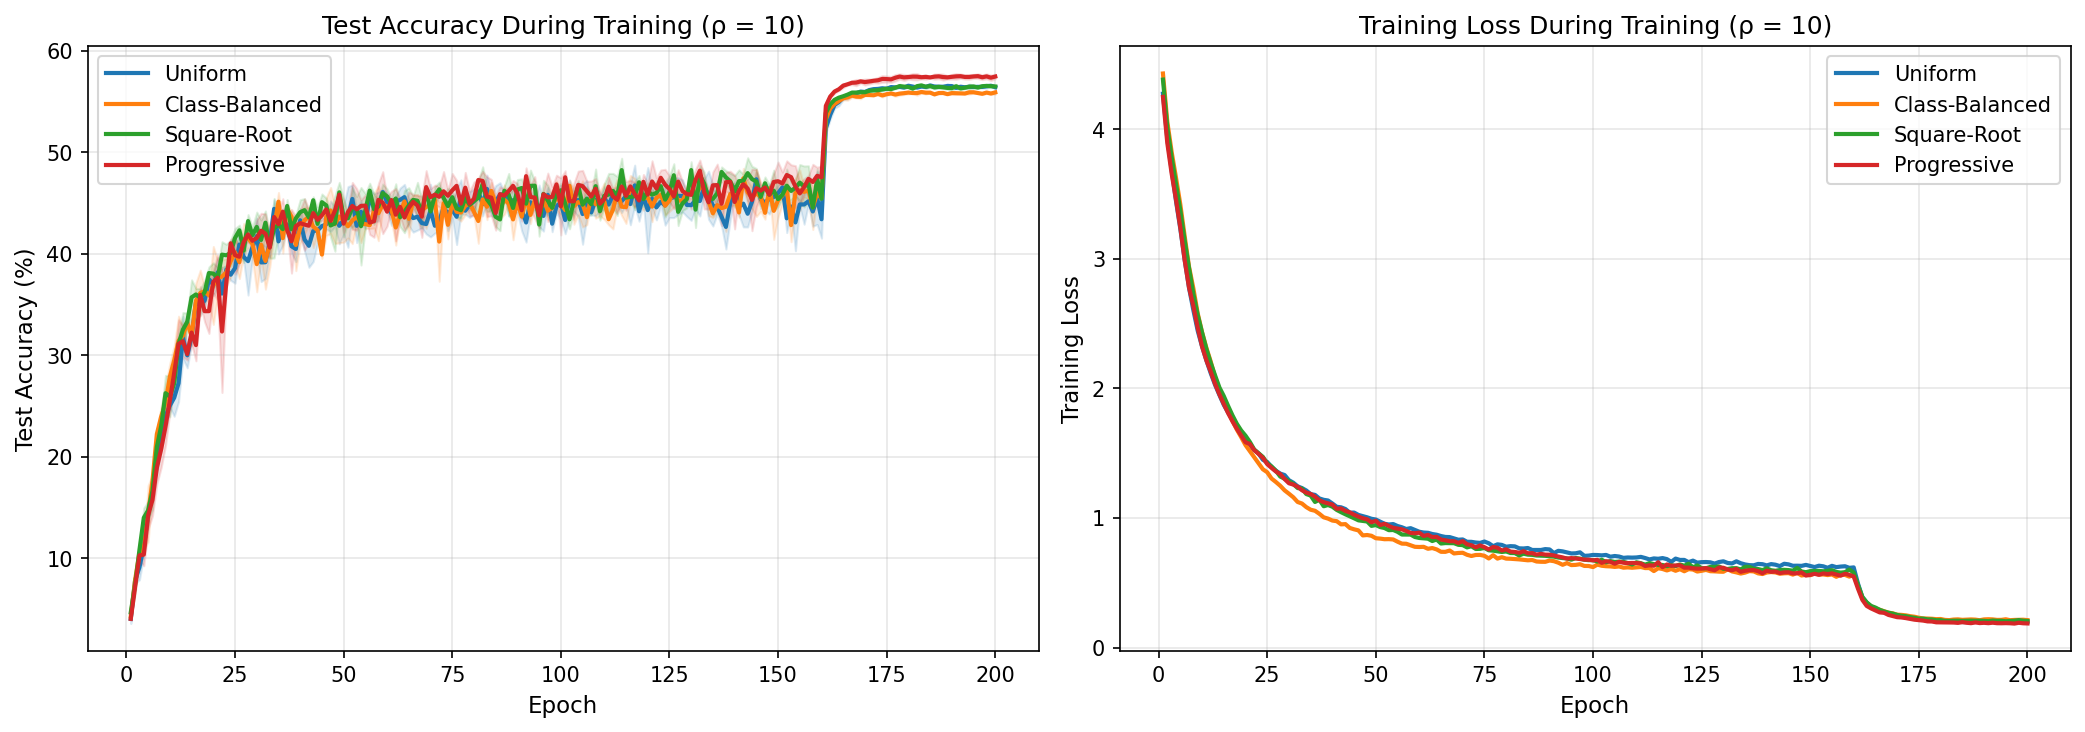


--- convergence_curves_rho100.png ---


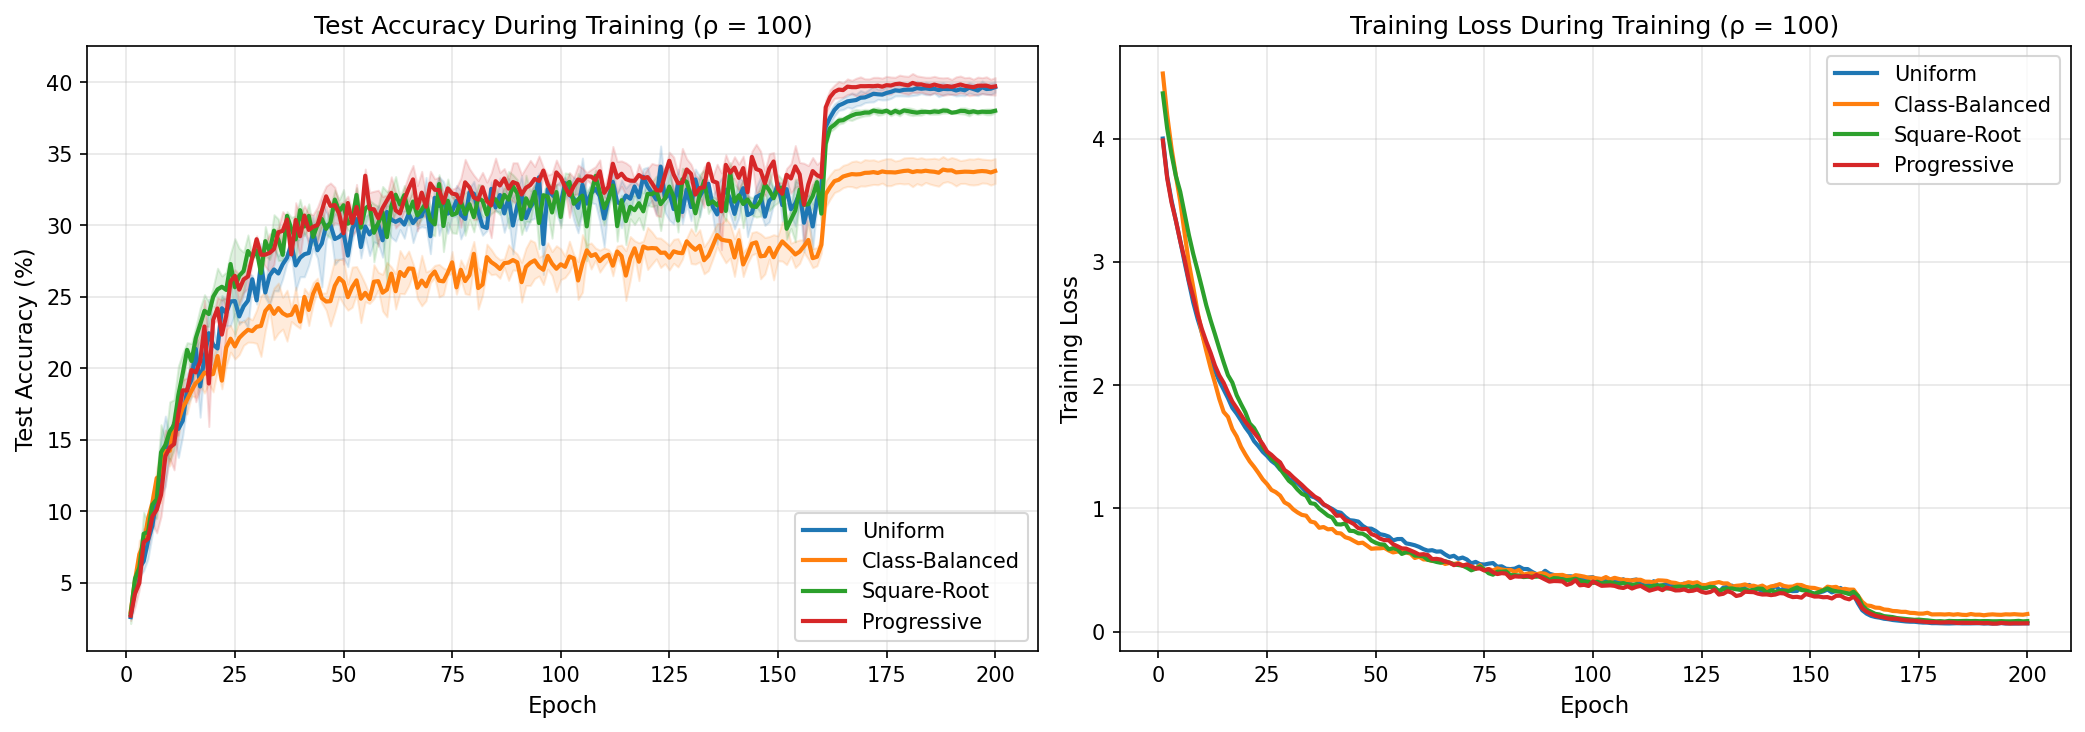


--- convergence_curves_rho50.png ---


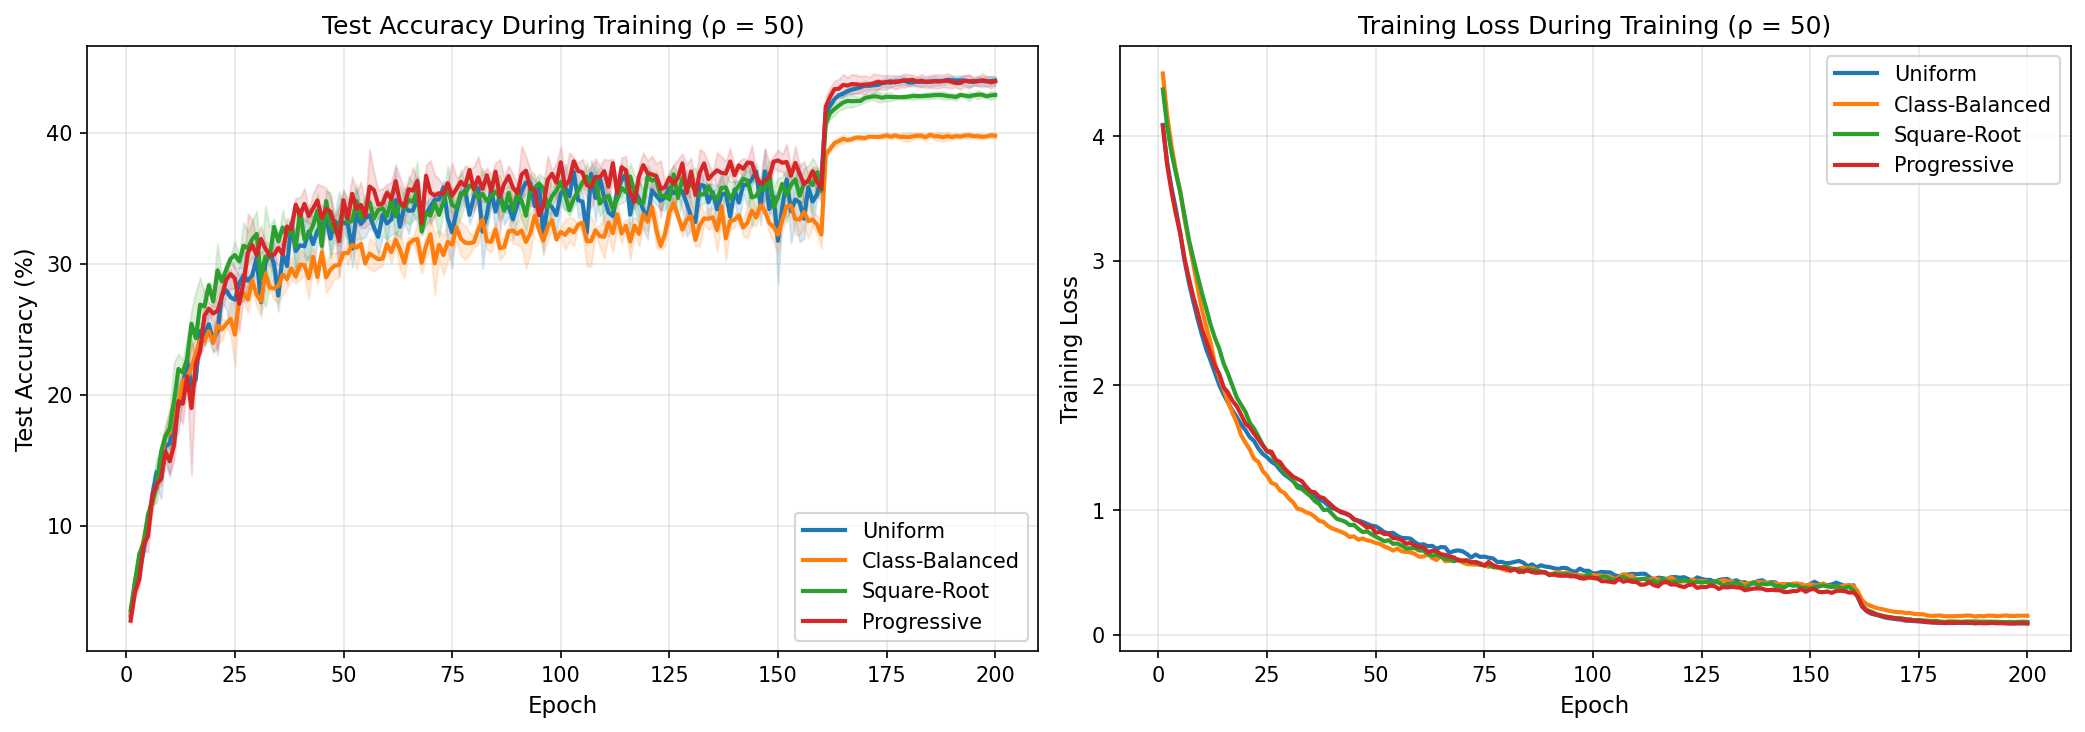


--- group_curves_rho10.png ---


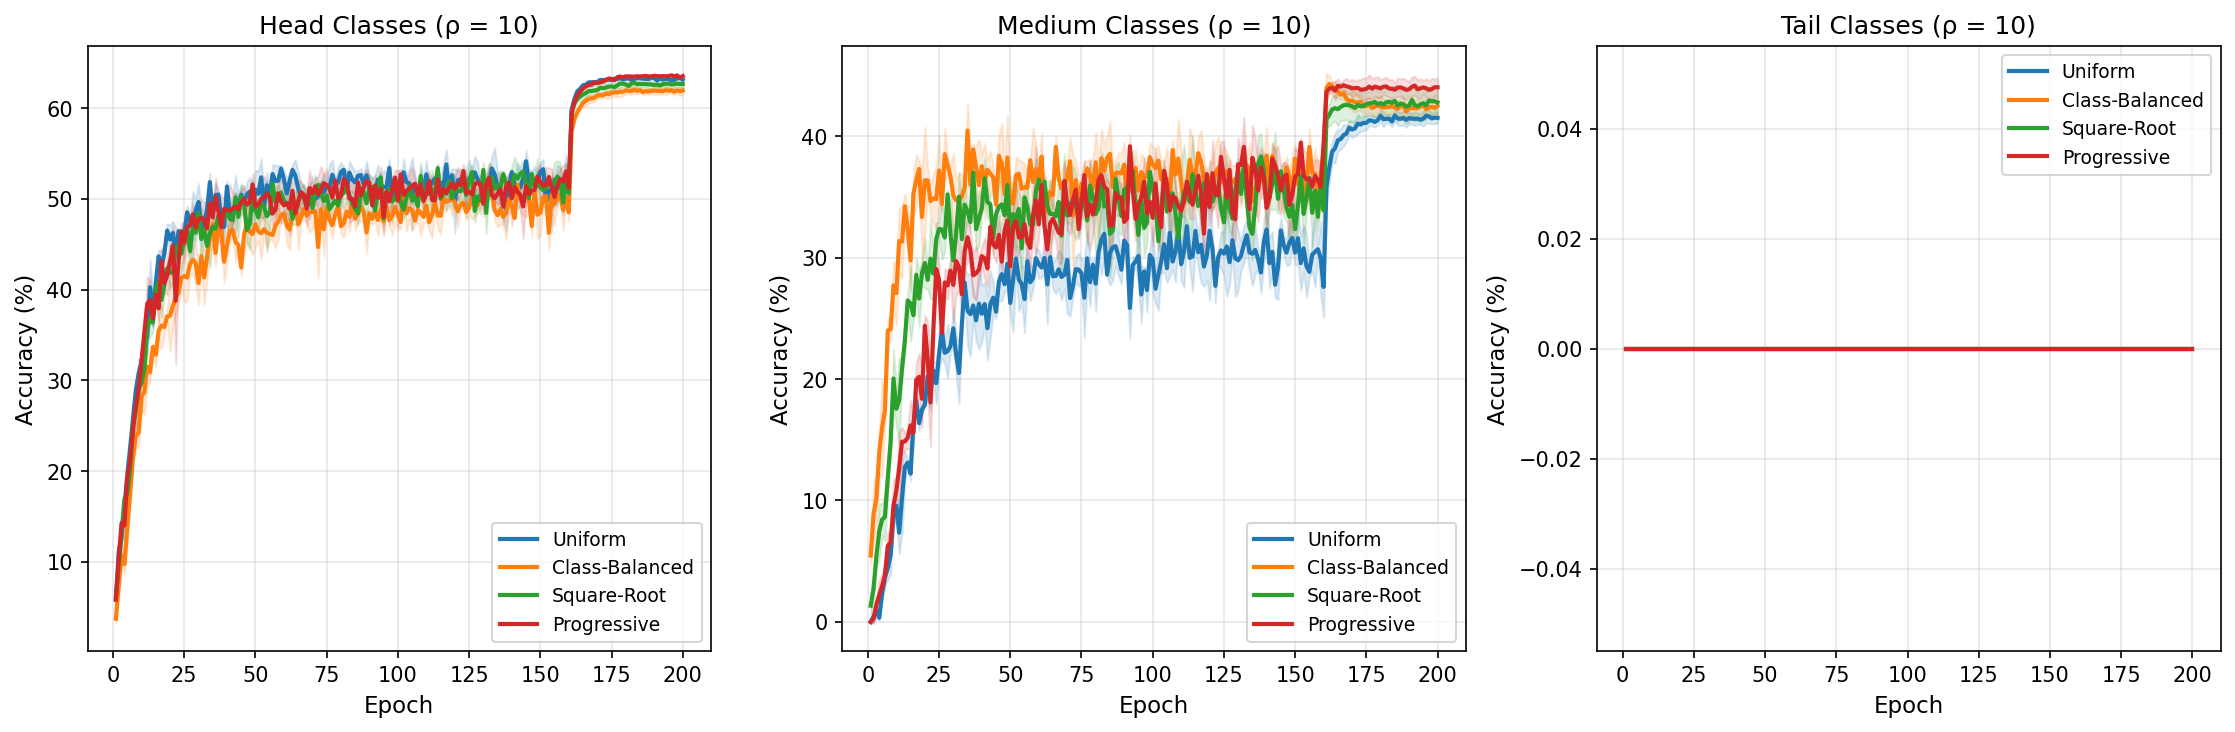


--- group_curves_rho100.png ---


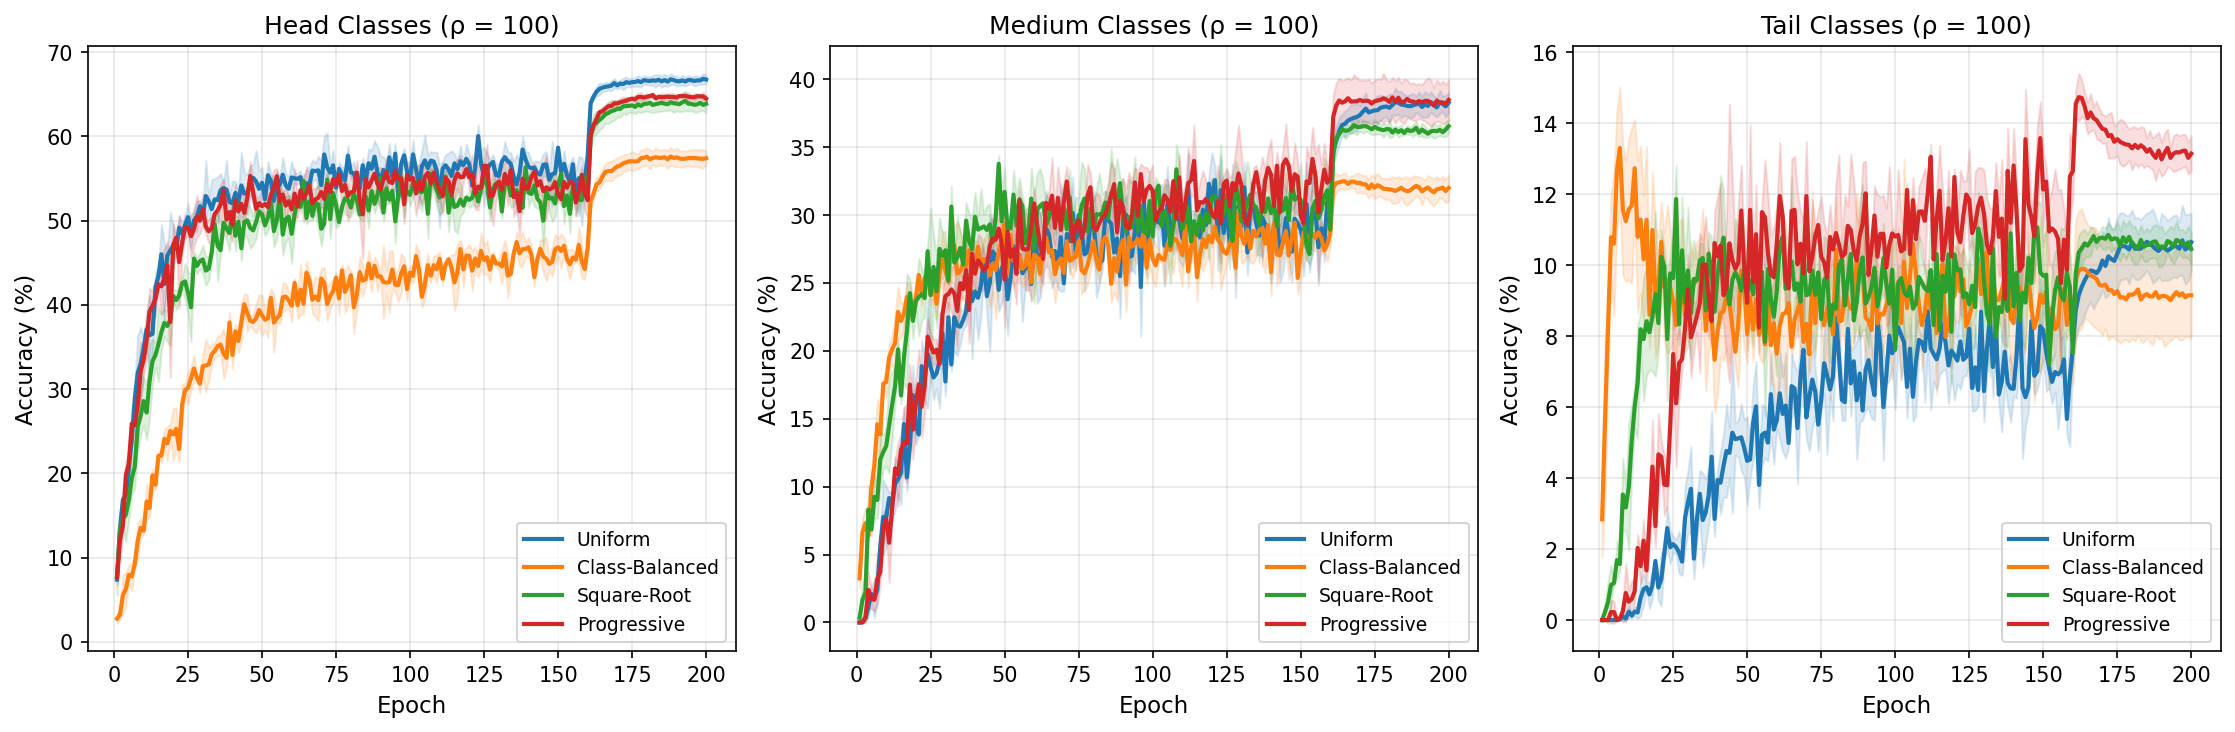


--- group_curves_rho50.png ---


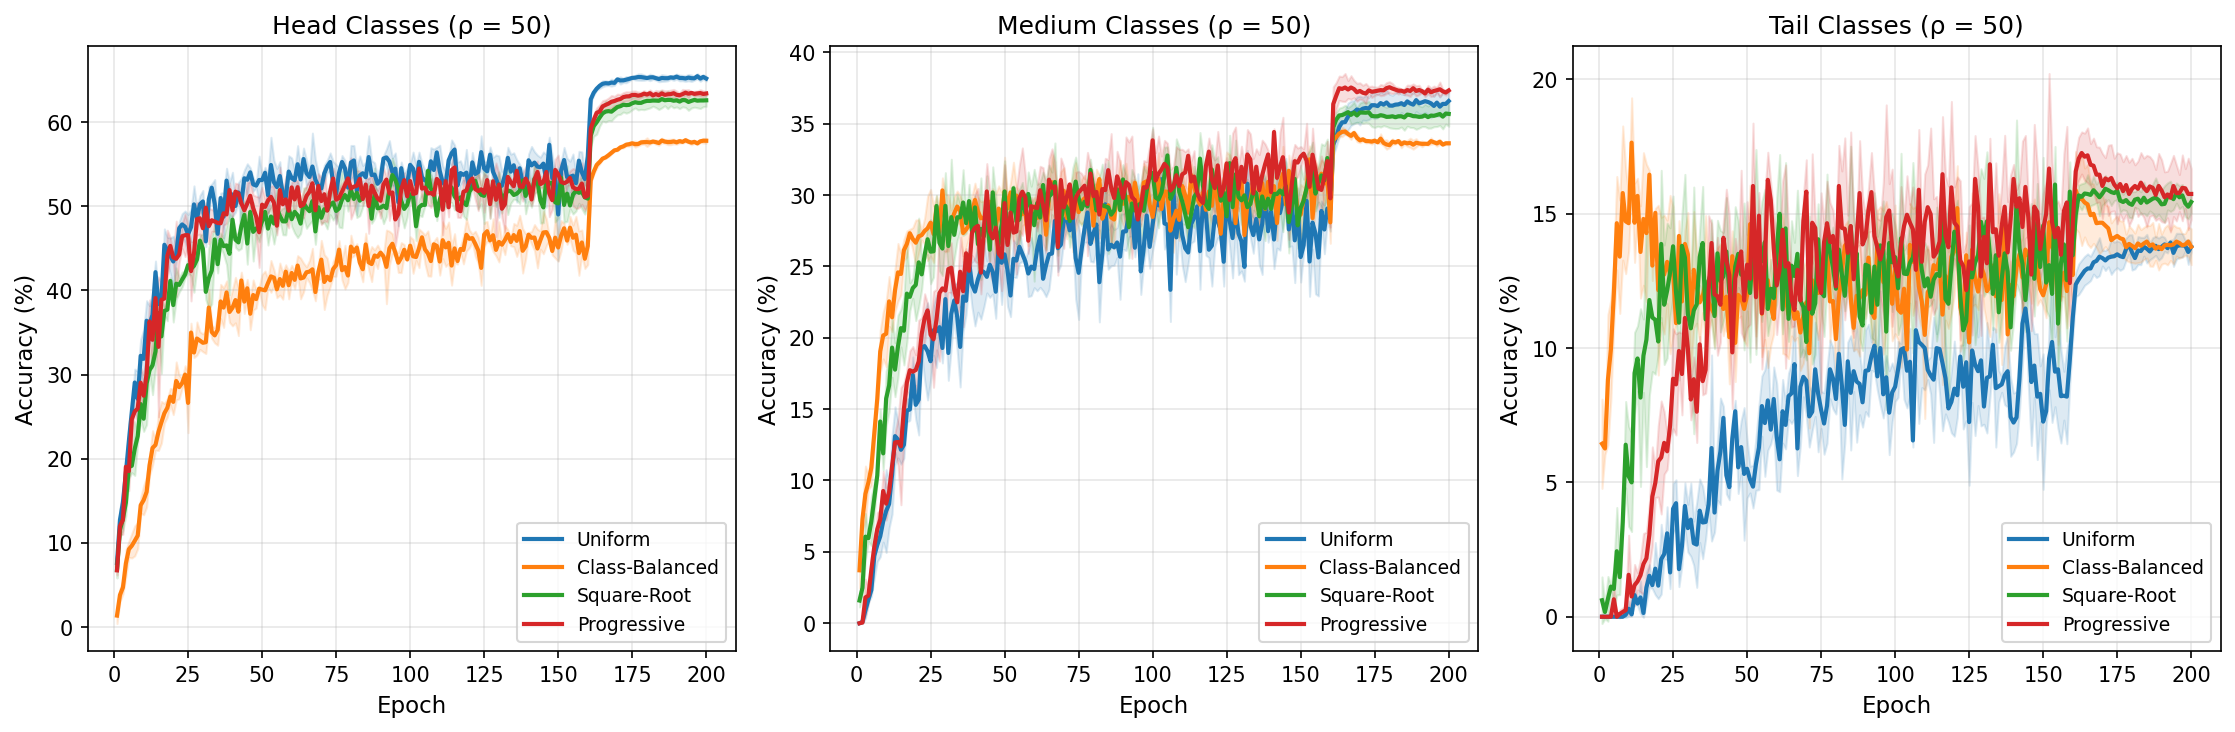


--- head_medium_tail_rho10.png ---


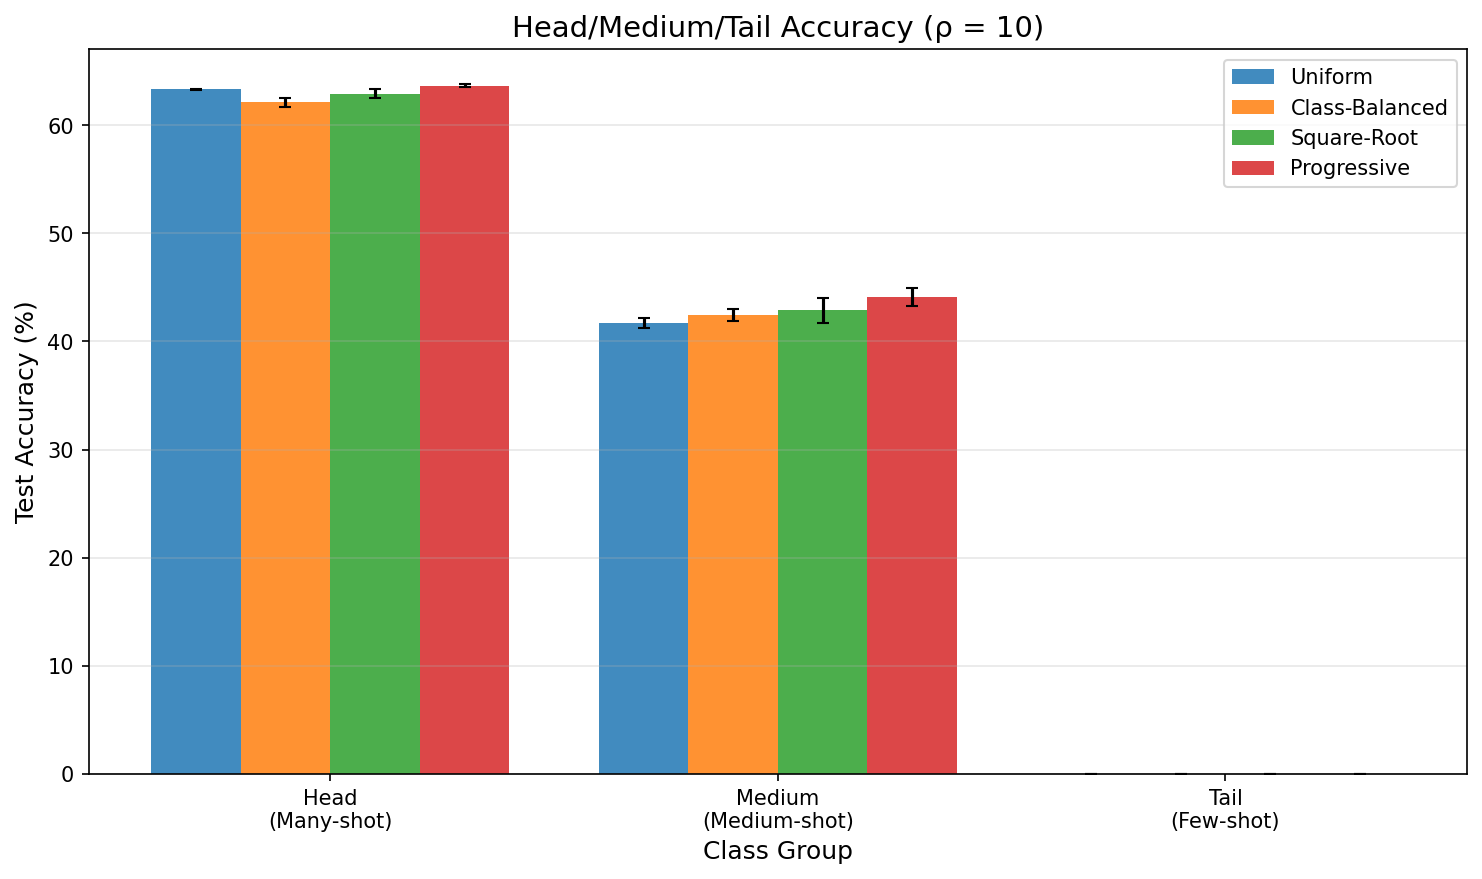


--- head_medium_tail_rho100.png ---


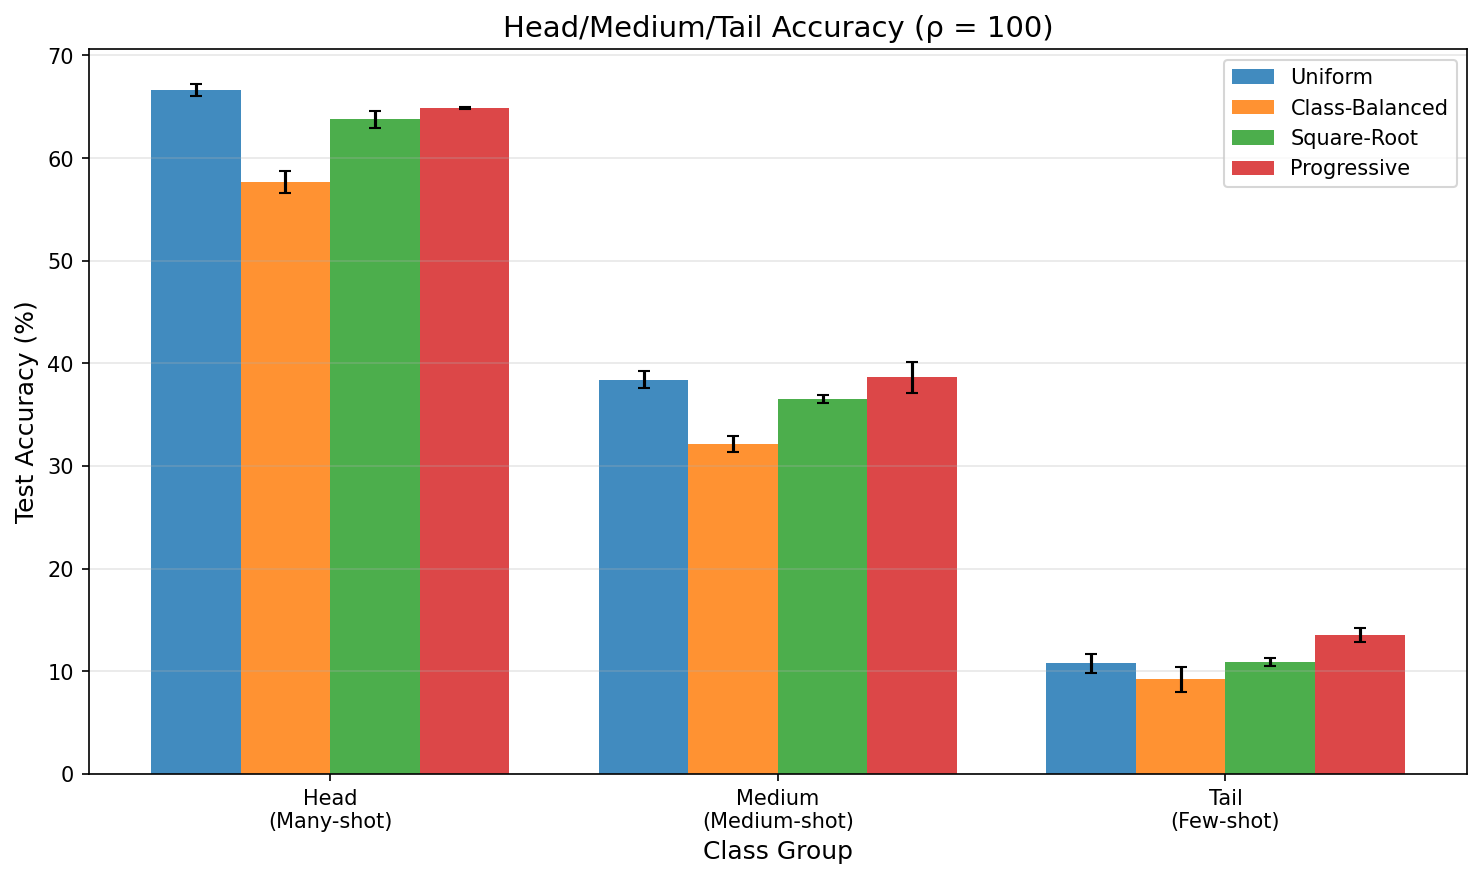


--- head_medium_tail_rho50.png ---


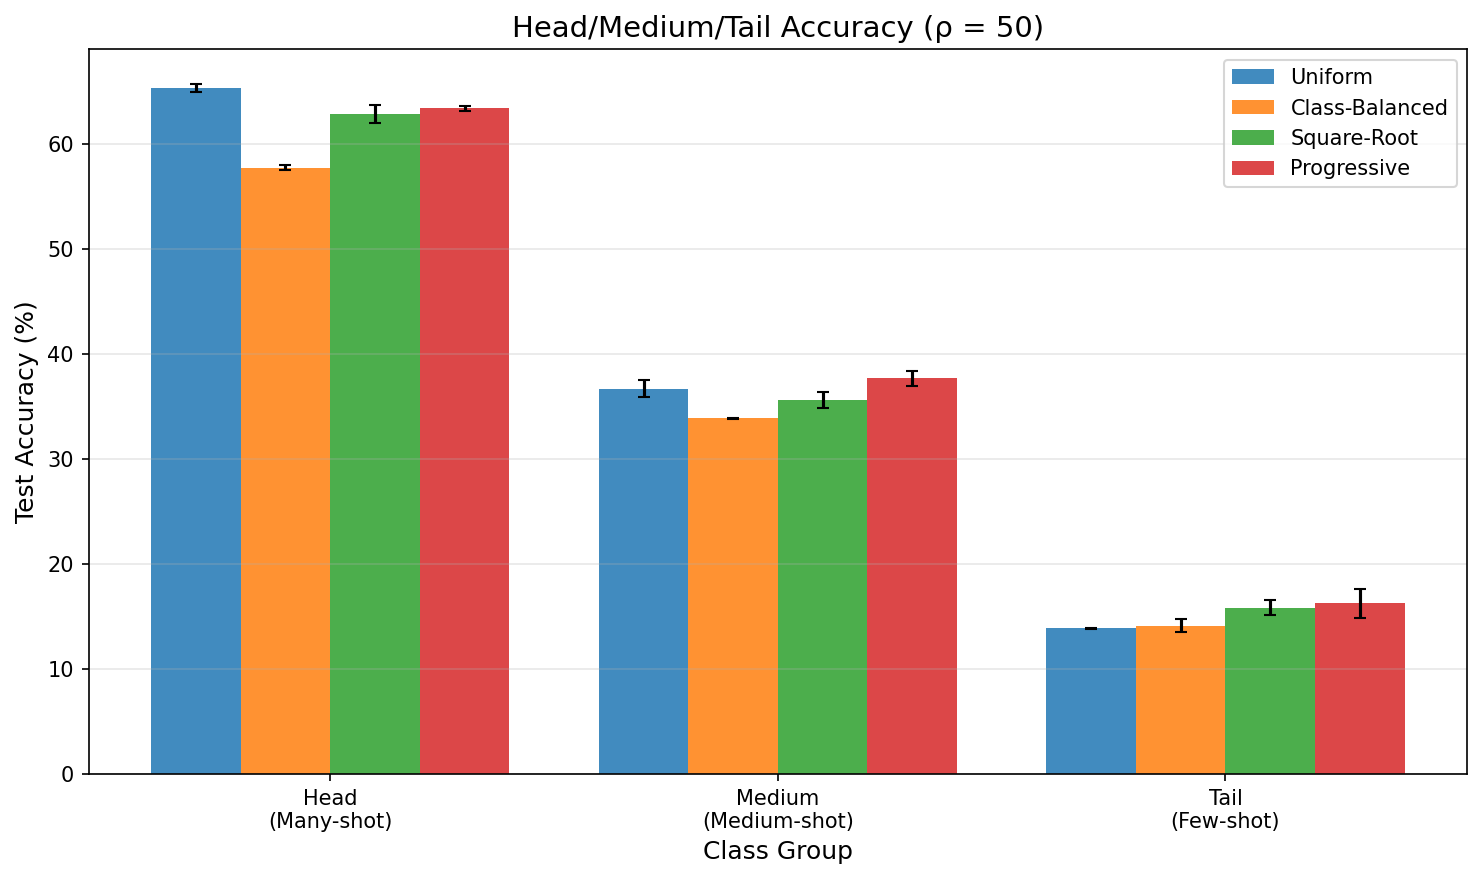


--- imbalance_effect.png ---


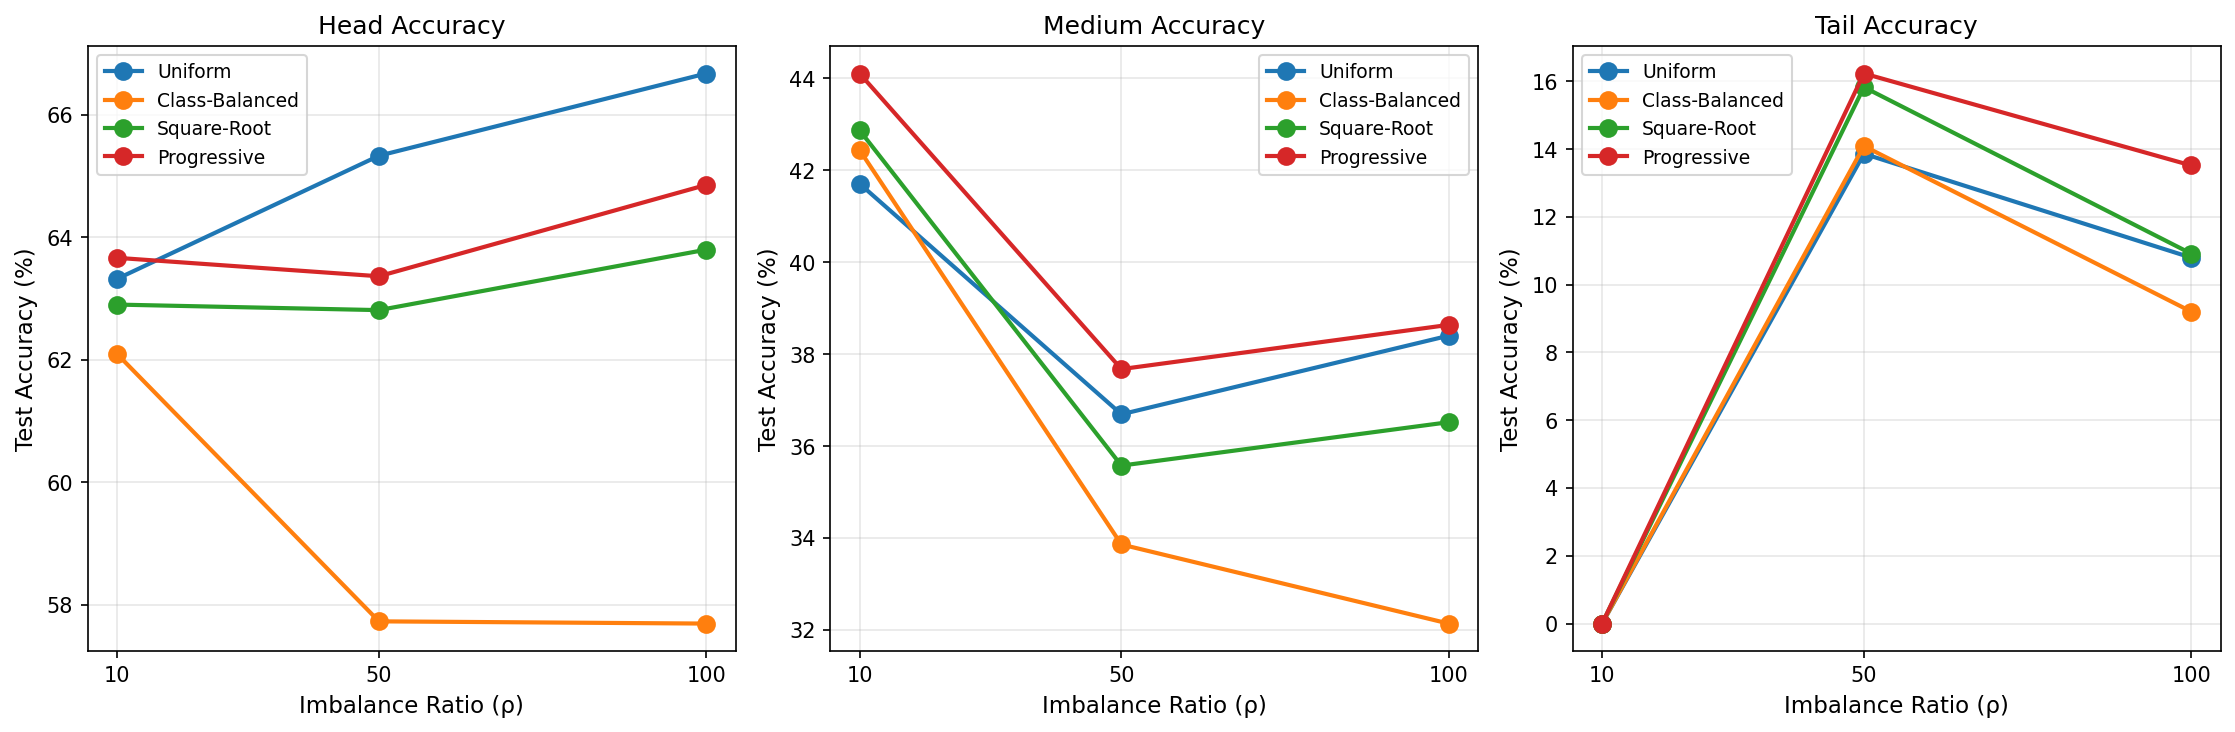


--- overall_accuracy_comparison.png ---


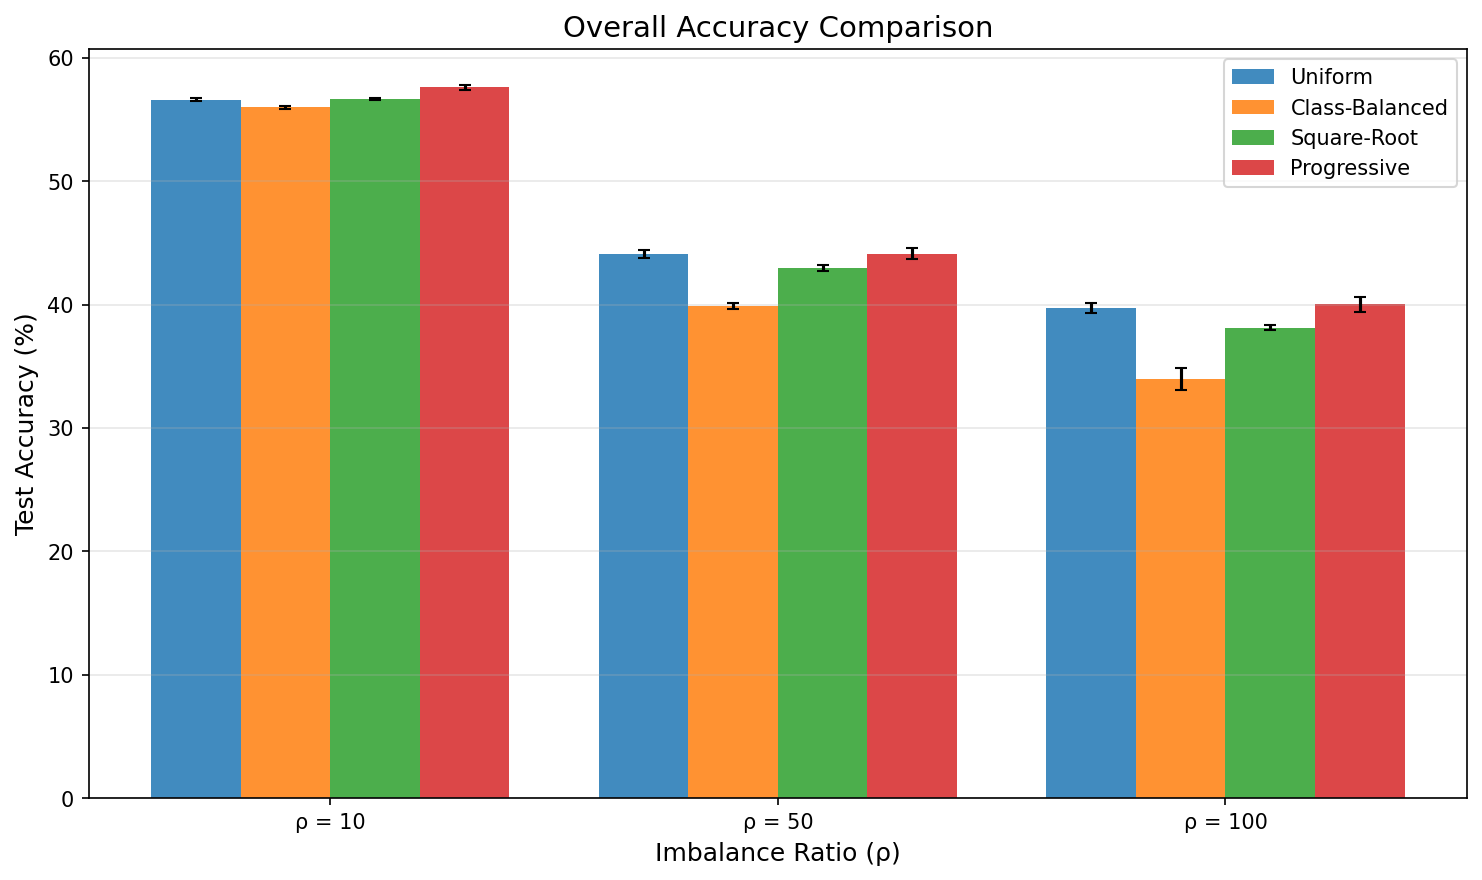

In [14]:
# Display saved figures inline
from IPython.display import Image, display
import os

fig_dir = CONFIG['figure_dir']
for fname in sorted(os.listdir(fig_dir)):
    if fname.endswith('.png'):
        print(f"\n--- {fname} ---")
        display(Image(os.path.join(fig_dir, fname)))